# Полиномиальная регрессия + регуляризация

Датасет: `load_diabetes` из sklearn — 442 записи, 10 признаков, target — числовая мера прогрессии диабета через год.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                  RidgeCV, LassoCV, ElasticNetCV)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
diabetes = load_diabetes(as_frame=True)
df = diabetes.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


## EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [4]:
df.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


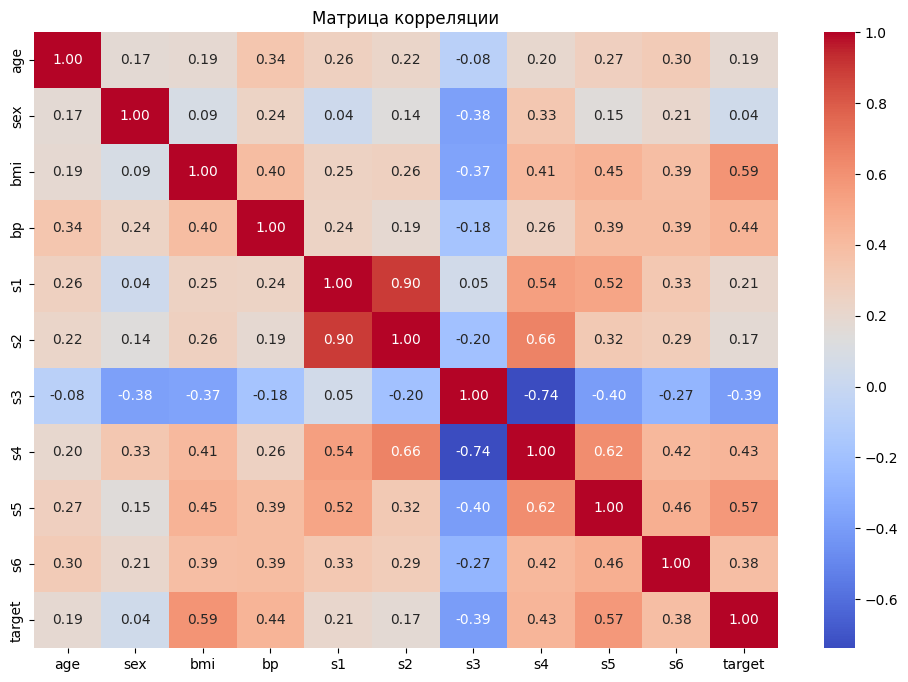

In [5]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции')
plt.show()

Наиболее коррелирующий признак: bmi (r=0.586)


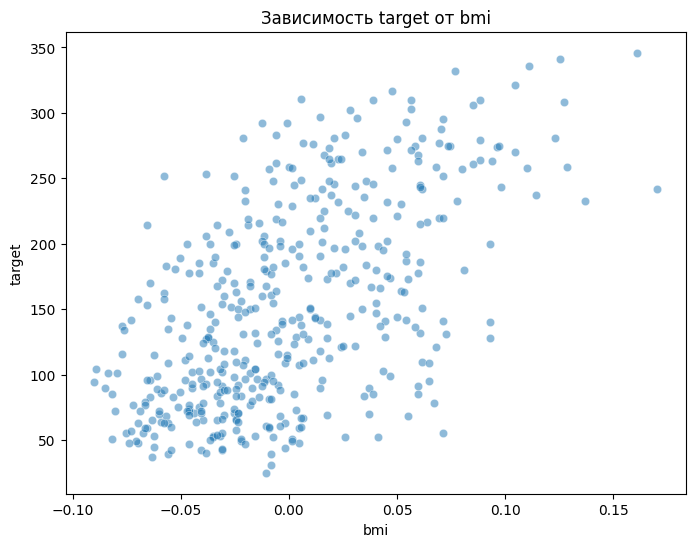

In [6]:
# Самый коррелирующий признак с target
corr_with_target = correlation_matrix['target'].drop('target').abs().sort_values(ascending=False)
best_feature = corr_with_target.index[0]
print(f'Наиболее коррелирующий признак: {best_feature} (r={correlation_matrix["target"][best_feature]:.3f})')

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=best_feature, y='target', alpha=0.5)
plt.title(f'Зависимость target от {best_feature}')
plt.show()

## Train/test split + StandardScaler

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape[0]} samples')
print(f'Test: {X_test_scaled.shape[0]} samples')

Train: 353 samples
Test: 89 samples


## Полиномиальная регрессия — поиск оптимальной степени

In [8]:
degrees = range(1, 6)
cv_means = []
cv_stds = []

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    
    model = LinearRegression()
    scores = cross_val_score(model, X_train_poly, y_train, cv=5, scoring='r2')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f'Degree {d}: R2 = {scores.mean():.4f} (+/- {scores.std():.4f}), features = {X_train_poly.shape[1]}')

best_degree = degrees[np.argmax(cv_means)]
print(f'\nОптимальная степень: {best_degree}')

Degree 1: R2 = 0.4493 (+/- 0.1441), features = 10
Degree 2: R2 = 0.3005 (+/- 0.1401), features = 65
Degree 3: R2 = -1067.7986 (+/- 713.1975), features = 285


Degree 4: R2 = -38.8776 (+/- 41.5520), features = 1000


Degree 5: R2 = -29.9397 (+/- 17.2096), features = 3002

Оптимальная степень: 1


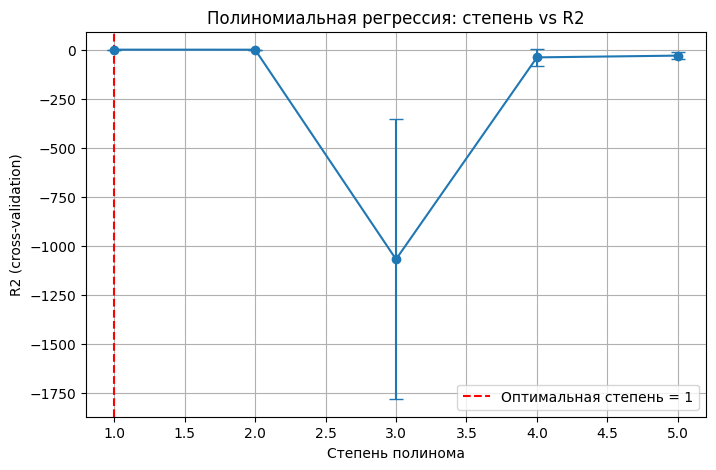

In [9]:
plt.figure(figsize=(8, 5))
plt.errorbar(list(degrees), cv_means, yerr=cv_stds, marker='o', capsize=5)
plt.axvline(x=best_degree, color='r', linestyle='--', label=f'Оптимальная степень = {best_degree}')
plt.xlabel('Степень полинома')
plt.ylabel('R2 (cross-validation)')
plt.title('Полиномиальная регрессия: степень vs R2')
plt.legend()
plt.grid(True)
plt.show()

## Регуляризация — сравнение Ridge, Lasso, ElasticNet

In [10]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f'Количество признаков после полиномиальных (degree={best_degree}): {X_train_poly.shape[1]}')

Количество признаков после полиномиальных (degree=1): 10


In [11]:
alphas = np.logspace(-4, 4, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train_poly, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_poly, y_train)

elastic_cv = ElasticNetCV(alphas=alphas, cv=5, random_state=42, max_iter=10000, l1_ratio=[0.1, 0.5, 0.7, 0.9])
elastic_cv.fit(X_train_poly, y_train)

print(f'Ridge  — лучший alpha: {ridge_cv.alpha_:.4f}')
print(f'Lasso  — лучший alpha: {lasso_cv.alpha_:.4f}')
print(f'ElasticNet — лучший alpha: {elastic_cv.alpha_:.4f}, l1_ratio: {elastic_cv.l1_ratio_:.2f}')

Ridge  — лучший alpha: 35.5648
Lasso  — лучший alpha: 1.7575
ElasticNet — лучший alpha: 0.1265, l1_ratio: 0.10


In [12]:
# Сравнение моделей по R2 и RMSE на тестовых данных
models = {
    'LinearRegression': LinearRegression().fit(X_train_poly, y_train),
    'Ridge': Ridge(alpha=ridge_cv.alpha_).fit(X_train_poly, y_train),
    'Lasso': Lasso(alpha=lasso_cv.alpha_, max_iter=10000).fit(X_train_poly, y_train),
    'ElasticNet': ElasticNet(alpha=elastic_cv.alpha_, l1_ratio=elastic_cv.l1_ratio_, max_iter=10000).fit(X_train_poly, y_train),
}

results = []
for name, model in models.items():
    pred = model.predict(X_test_poly)
    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    results.append({'Модель': name, 'R2': round(r2, 4), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)})

results_df = pd.DataFrame(results)
results_df

,Модель,R2,RMSE,MAE
0,LinearRegression,0.4526,53.85,42.79
1,Ridge,0.4602,53.48,42.97
2,Lasso,0.4715,52.91,42.81
3,ElasticNet,0.4606,53.46,42.99


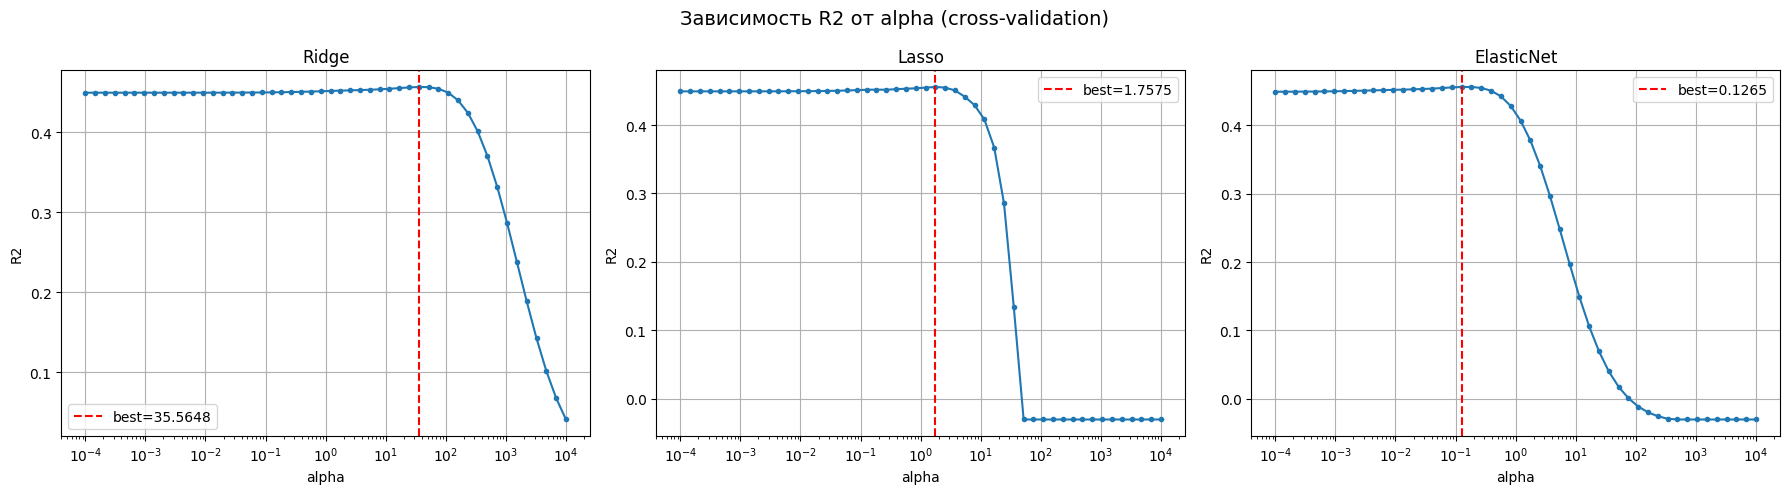

In [13]:
# График: alpha vs R2 для Ridge, Lasso, ElasticNet
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ridge
ridge_scores = []
for a in alphas:
    scores = cross_val_score(Ridge(alpha=a), X_train_poly, y_train, cv=5, scoring='r2')
    ridge_scores.append(scores.mean())
axes[0].plot(alphas, ridge_scores, marker='.')
axes[0].axvline(x=ridge_cv.alpha_, color='r', linestyle='--', label=f'best={ridge_cv.alpha_:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('R2')
axes[0].set_title('Ridge')
axes[0].legend()
axes[0].grid(True)

# Lasso
lasso_scores = []
for a in alphas:
    scores = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_poly, y_train, cv=5, scoring='r2')
    lasso_scores.append(scores.mean())
axes[1].plot(alphas, lasso_scores, marker='.')
axes[1].axvline(x=lasso_cv.alpha_, color='r', linestyle='--', label=f'best={lasso_cv.alpha_:.4f}')
axes[1].set_xscale('log')
axes[1].set_xlabel('alpha')
axes[1].set_ylabel('R2')
axes[1].set_title('Lasso')
axes[1].legend()
axes[1].grid(True)

# ElasticNet
elastic_scores = []
for a in alphas:
    scores = cross_val_score(ElasticNet(alpha=a, l1_ratio=elastic_cv.l1_ratio_, max_iter=10000),
                             X_train_poly, y_train, cv=5, scoring='r2')
    elastic_scores.append(scores.mean())
axes[2].plot(alphas, elastic_scores, marker='.')
axes[2].axvline(x=elastic_cv.alpha_, color='r', linestyle='--', label=f'best={elastic_cv.alpha_:.4f}')
axes[2].set_xscale('log')
axes[2].set_xlabel('alpha')
axes[2].set_ylabel('R2')
axes[2].set_title('ElasticNet')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Зависимость R2 от alpha (cross-validation)', fontsize=14)
plt.tight_layout()
plt.show()

## Финальная модель и метрики

In [14]:
# Выбираем лучшую модель по R2 на test
best_name = results_df.loc[results_df['R2'].idxmax(), 'Модель']
best_model = models[best_name]
print(f'Лучшая модель: {best_name}')

y_pred = best_model.predict(X_test_poly)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2:   {r2:.4f}')

Лучшая модель: Lasso
MAE:  42.81
RMSE: 52.91
R2:   0.4715


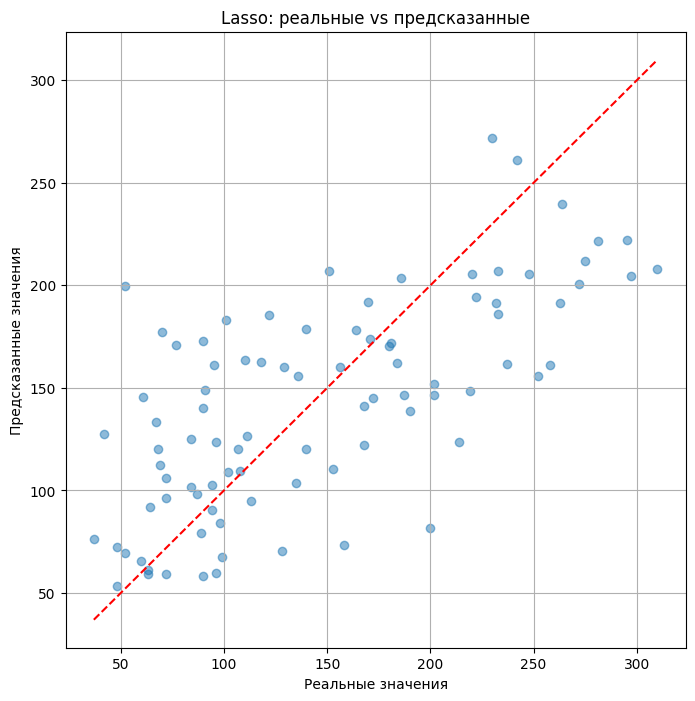

In [15]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='red')

plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title(f'{best_name}: реальные vs предсказанные')
plt.grid(True)
plt.show()